# Matrix Determinant Code Challenges and Solutions to Practice Questions

## Code Challenge 1: Determinant of singular (reduced-rank) matrices.

- Generate a 2 x 2 matrix of ints with linear dependencies, then compute determinant.
- Generate N x N matrices of ints with linear dependencies, compute determinant. (for small (2-5) and large Ns (20-30))

In [1]:
import numpy as np

A = np.random.randint(0, 10, (2, 2))
A[1] = A[0] * np.random.randint(0, 10, 1)
print(A)
print("Rank:", np.linalg.matrix_rank(A))

print("Determinant:", round(np.linalg.det(A), 1))

[[ 7  7]
 [21 21]]
Rank: 1
Determinant: -0.0


In [67]:
small = 6
large = 30

print("=== Small Matrix ===")
S = np.random.randint(0, 10, (small, small))
S[1] = S[0] * np.random.randint(0, 10, 1)
print(S)
print("Rank:", np.linalg.matrix_rank(S))

print("Determinant:", round(np.linalg.det(S), 1))

print("=== Large Matrix ===")
L = np.random.randint(0, 10, (large, large))
L[1] = L[0] * np.random.randint(0, 10, 1)
print("Rank:", np.linalg.matrix_rank(L))

print("Determinant:", round(np.linalg.det(L), 1))

=== Small Matrix ===
[[ 7  3  8  6  7  5]
 [28 12 32 24 28 20]
 [ 3  8  7  7  9  1]
 [ 3  2  9  3  5  8]
 [ 5  4  3  8  7  6]
 [ 5  4  9  5  5  6]]
Rank: 5
Determinant: 0.0
=== Large Matrix ===
Rank: 29
Determinant: 0.0


## Code Challenge 2: Large matrices with row exchanges

- Generate a 6 x 6 matrix
- Compute the det
- Swap 1 row
- Compute the det
- Swap 2 rows
- Compute the det

In [18]:
A = np.random.randint(0, 10, (6, 6))
print("Original Matrix:\n", A)
print("Rank", np.linalg.matrix_rank(A))
print("Determinant:", np.linalg.det(A))

Original Matrix:
 [[6 4 1 6 7 6]
 [5 6 9 6 3 5]
 [3 0 2 4 9 1]
 [7 3 7 0 4 5]
 [3 7 0 3 2 3]
 [3 8 6 1 4 3]]
Rank 6
Determinant: -27984.000000000015


In [ ]:
# My method:
# A_1swap = A.copy()
# A_1swap[1] = A[2]
# A_1swap[2] = A[1]

# Better method:
A_1swap = A[[0, 2, 1, 3, 4, 5]]
print("Swapped 1 Row Matrix:\n", A_1swap)
print("Rank", np.linalg.matrix_rank(A_1swap))
print("Determinant:", round(np.linalg.det(A_1swap), 2))

Original Matrix:
 [[6 4 1 6 7 6]
 [3 0 2 4 9 1]
 [5 6 9 6 3 5]
 [7 3 7 0 4 5]
 [3 7 0 3 2 3]
 [3 8 6 1 4 3]]
Rank 6
Determinant: 27984.0


In [26]:
# My method:
# A_2swap = A.copy()
# A_2swap[1] = A[2]
# A_2swap[2] = A[1]
# A_2swap[3] = A[4]
# A_2swap[4] = A[3]

# Better method:
A_2swap = A[[0, 2, 1, 4, 3, 5]]
print("Swapped 2 Rows Matrix:\n", A_2swap)
print("Rank", np.linalg.matrix_rank(A_2swap))
print("Determinant:", round(np.linalg.det(A_2swap), 2))

Swapped 2 Rows Matrix:
 [[6 4 1 6 7 6]
 [3 0 2 4 9 1]
 [5 6 9 6 3 5]
 [3 7 0 3 2 3]
 [7 3 7 0 4 5]
 [3 8 6 1 4 3]]
Rank 6
Determinant: -27984.0


In [27]:
# Column swaps now:
print("Original Matrix:\n", A)
A_1colSwap = A[:, [0, 2, 1, 3, 4, 5]]
print("Swapped 1 Column:\n", A_1colSwap)
print("Rank", np.linalg.matrix_rank(A_1colSwap))
print("Determinant:", round(np.linalg.det(A_1colSwap), 2))

Original Matrix:
 [[6 4 1 6 7 6]
 [5 6 9 6 3 5]
 [3 0 2 4 9 1]
 [7 3 7 0 4 5]
 [3 7 0 3 2 3]
 [3 8 6 1 4 3]]
Swapped 1 Column:
 [[6 1 4 6 7 6]
 [5 9 6 6 3 5]
 [3 2 0 4 9 1]
 [7 7 3 0 4 5]
 [3 0 7 3 2 3]
 [3 6 8 1 4 3]]
Rank 6
Determinant: 27984.0


In [29]:
A_2colSwap = A[:, [0, 2, 1, 4, 3, 5]]
print("Swapped 2 Column:\n", A_2colSwap)
print("Rank", np.linalg.matrix_rank(A_2colSwap))
print("Determinant:", round(np.linalg.det(A_2colSwap), 2))

Swapped 2 Column:
 [[6 1 4 7 6 6]
 [5 9 6 3 6 5]
 [3 2 0 9 4 1]
 [7 7 3 4 0 5]
 [3 0 7 2 3 3]
 [3 6 8 4 1 3]]
Rank 6
Determinant: -27984.0


## Code Challenge 3: Determinant of shifted matrices

- Generate a random matrix (20x20)
- Impose a linear depedency
- "Shift" the matrix by lambda (0 to 0.1 times the identity matrix)
- Compute the abs(det) of the shifted matrix
- Do this 1000 times and average

- Loop to span a range of lambdas
- Plot the det as a function of lambda

In [84]:
# No of iterations for computing individual det
k = 1000

# Lambdas from 0:0.1, 100 times
l = np.linspace(0.001, 0.1, 100)

list_avg_det = []
# Loop over lambas
for i in range(0, len(l)):

    list_det = []
    for j in range(0, k):
        # Create random 20 x 20 matrix
        A = np.random.randn(20, 20)
        # Add linear dependence at row 3
        A[3] = A[0]
        # Create identity matrix * lambda
        Il = np.identity(20) * l[i]

        # Scale A by Il
        current_det = abs(np.linalg.det(A + Il))
        list_det = np.append(list_det, current_det)

    list_avg_det = np.append(list_avg_det, np.mean(list_det))

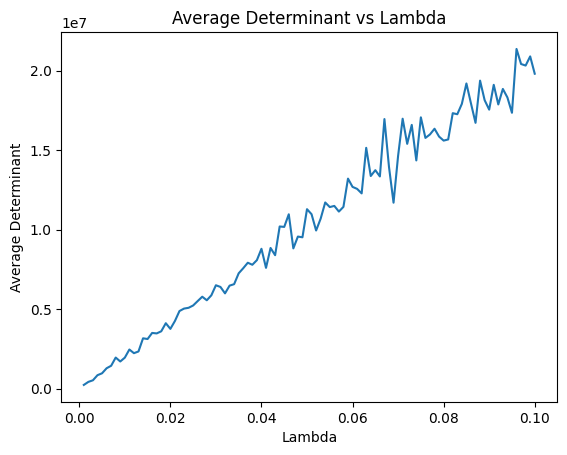

In [ ]:
import matplotlib.pyplot as plt

plt.plot(l, list_avg_det)
plt.xlabel("Lambda (from 0.001 to 0.1)")
plt.ylabel("Average Determinant")
plt.title("Average Determinant vs Lambda")
plt.show()

## Code Challenge 4: Illustrate that $det(AB) = det(A) * det(B)$

1) Generate a random matrix (3x3) and show that the above holds
2) Generate random matrices (NxN) of up to 40 and show the above holds


In [ ]:
A = np.random.randn(3, 3)
B = np.random.randn(3, 3)

detAB = np.linalg.det(A @ B)

print("Det(AB) = ", detAB)

detAxB = np.linalg.det(A) * np.linalg.det(B)

print("Det(A) * Det(B) = ", detAxB)

Det(AB) =  -0.4123367437733636
Det(A) * Det(b) =  -0.4123367437733639


(-5.0, 5.0)

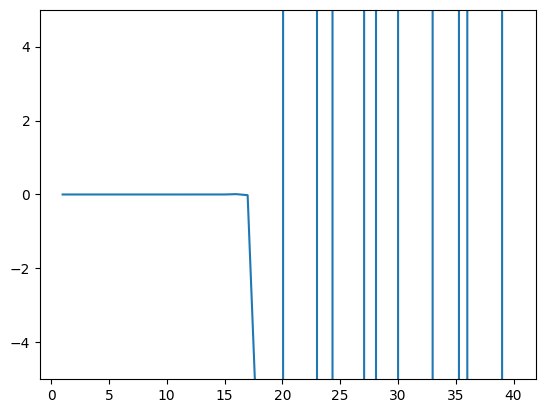

In [119]:
all_detCD = np.zeros([40, 3])

for N in range(1, 41):
    C = np.random.randn(N, N)
    D = np.random.randn(N, N)

    detCD = np.linalg.det(C @ D)
    detCxD = np.linalg.det(C) * np.linalg.det(D)

    all_detCD[N - 1, 0] = N
    all_detCD[N - 1, 1] = detCD
    all_detCD[N - 1, 2] = detCxD

plt.plot(all_detCD[:, 0], all_detCD[:, 1] - all_detCD[:, 2])
plt.ylim(-5, 5)